In [1]:
# Sensor-based vehicle count to light usage prediction (simple implementation)

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



np.random.seed(42)



# Simulated sensor data (vehicle count per interval)

n_samples = 240

vehicle_count = np.random.poisson(lam=18, size=n_samples)



# Nonlinear relation: higher vehicle count generally needs more light usage

# Light usage unit can represent % brightness or watt-equivalent index

noise = np.random.normal(0, 2.0, size=n_samples)

light_usage = 0.06 * (vehicle_count ** 2) + 1.8 * vehicle_count + 8 + noise



data = pd.DataFrame({

    "vehicle_count": vehicle_count,

    "light_usage": light_usage

})

data.head()


,vehicle_count,light_usage
0,21,73.488333
1,13,43.055015
2,19,62.798998
3,23,79.988364
4,13,40.989897


In [3]:
# Train/test split

X = data[["vehicle_count"]]

y = data["light_usage"]



X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42

)



# Polynomial regression model

poly_degree = 2

model = Pipeline([

    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),

    ("reg", LinearRegression())

])



model.fit(X_train, y_train)

y_pred = model.predict(X_test)



# Performance metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)



metrics_df = pd.DataFrame({

    "Metric": ["MAE", "RMSE", "R2"],

    "Value": [mae, rmse, r2]

})

metrics_df


,Metric,Value
0,MAE,1.613077
1,RMSE,2.026286
2,R2,0.988325


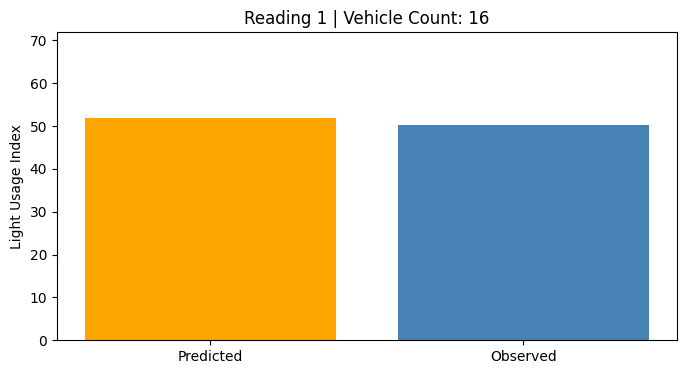

ALERT at reading 10: vehicle_count=24, pred=85.82, obs=97.04, deviation=11.22
ALERT at reading 20: vehicle_count=16, pred=51.87, obs=63.95, deviation=12.07
ALERT at reading 30: vehicle_count=17, pred=55.64, obs=69.07, deviation=13.43
Total alerts: 3


In [5]:
# Real-time style bar chart with anomaly alerts

plt.ion()

fig, ax = plt.subplots(figsize=(8, 4))



# Alert threshold based on training residual standard deviation

train_pred = model.predict(X_train)

train_residual_std = np.std(y_train - train_pred)

anomaly_threshold = 2.5 * train_residual_std



# Simulated incoming sensor stream (latest 30 readings)

stream_counts = np.random.poisson(lam=18, size=30)

alerts = []



for i, count in enumerate(stream_counts, start=1):

    input_row = pd.DataFrame({"vehicle_count": [count]})

    predicted_light = float(model.predict(input_row)[0])



    # Simulate observed value from physical light sensor

    observed_light = predicted_light + np.random.normal(0, 2.0)



    # Inject occasional anomalies for demonstration

    if i % 10 == 0:

        observed_light += np.random.choice([12, -12])



    deviation = abs(observed_light - predicted_light)

    is_anomaly = deviation > anomaly_threshold

    color = "red" if is_anomaly else "steelblue"



    ax.clear()

    ax.bar(["Predicted", "Observed"], [predicted_light, observed_light], color=["orange", color])

    ax.set_ylim(0, max(predicted_light, observed_light) + 20)

    ax.set_title(f"Reading {i} | Vehicle Count: {count}")

    ax.set_ylabel("Light Usage Index")



    if is_anomaly:

        alert_msg = (

            f"ALERT at reading {i}: vehicle_count={count}, "

            f"pred={predicted_light:.2f}, obs={observed_light:.2f}, deviation={deviation:.2f}"

        )

        print(alert_msg)

        alerts.append(alert_msg)



    plt.pause(0.25)



plt.ioff()

plt.show()



print(f"Total alerts: {len(alerts)}")


In [7]:
# Write performance metrics to CSV

from pathlib import Path



metrics_output_path = Path.cwd() / "performance_metrics_week8.csv"

metrics_df.to_csv(metrics_output_path, index=False)



print("Performance Metrics")

print(metrics_df)

print(f"Saved metrics to: {metrics_output_path}")


Performance Metrics
  Metric     Value
0    MAE  1.613077
1   RMSE  2.026286
2     R2  0.988325
Saved metrics to: e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\6th SEM\Hack-O-Week\Week 8\performance_metrics_week8.csv
